## [프로그램 5-1] YOLOv8 모델 불러오기

In [28]:
import torch

# YOLO 설치
!pip install ultralytics
from ultralytics import YOLO

# 장치 선택
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# 사전 학습된 모델 로드
model = YOLO("yolov8n.pt").to(device)

Using device: cpu


## [프로그램 5-2] 테스트 이미지 불러오기



## [프로그램 5-3] 모델 추론 실행하기


In [34]:
results = model.predict("/content/스크린샷 2026-09-26 123304.jpg", device=device)




image 1/1 /content/스크린샷 2026-09-26 123304.jpg: 640x512 12 persons, 3 cars, 209.6ms
Speed: 7.7ms preprocess, 209.6ms inference, 2.8ms postprocess per image at shape (1, 3, 640, 512)


## [프로그램 5-4] 탐지 결과를 텍스트로 확인하기

In [35]:
for r in results:
    for box in r.boxes:
        cls_id = int(box.cls)
        score = float(box.conf)
        x1, y1, x2, y2 = box.xyxy[0].tolist()   # 경계 상자 좌표
        print(f"class={cls_id}, score={score:.3f}, box=({x1:.1f},{y1:.1f})-({x2:.1f},{y2:.1f})")



class=2, score=0.735, box=(202.8,519.4)-(250.8,557.5)
class=2, score=0.670, box=(130.5,517.9)-(187.0,543.5)
class=0, score=0.566, box=(13.9,515.6)-(39.9,560.8)
class=0, score=0.490, box=(41.4,514.9)-(61.6,560.7)
class=0, score=0.448, box=(65.1,517.5)-(78.5,560.0)
class=0, score=0.423, box=(105.3,518.8)-(119.6,560.9)
class=2, score=0.406, box=(126.9,538.2)-(209.6,560.7)
class=0, score=0.401, box=(116.1,520.2)-(132.4,559.8)
class=0, score=0.388, box=(286.2,518.1)-(300.5,553.3)
class=0, score=0.386, box=(366.0,517.0)-(378.1,550.7)
class=0, score=0.370, box=(88.1,515.0)-(109.3,560.9)
class=0, score=0.321, box=(47.8,513.7)-(63.4,560.8)
class=0, score=0.312, box=(74.2,520.5)-(89.0,561.0)
class=0, score=0.273, box=(397.5,513.2)-(408.3,543.3)
class=0, score=0.261, box=(372.9,514.3)-(385.3,551.2)


## [프로그램 5-5] 탐지 결과를 시각화하기


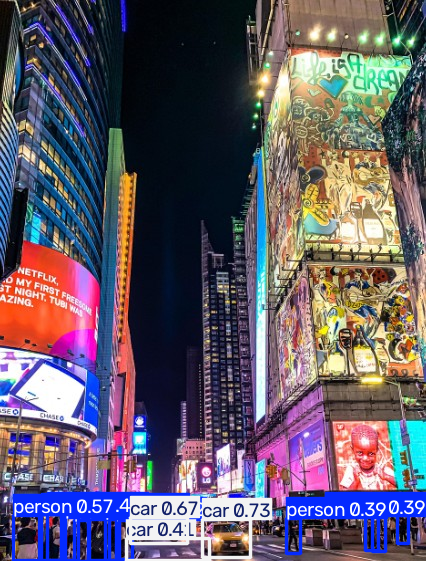

In [36]:
results[0].save("detected.jpg")      # 탐지 결과 이미지 저장
results[0].show()                    # 주피터/콜랩 환경에서 시각화

